In [5]:
import pandas as pd
import os

# 1. Tự động tìm đường dẫn file AIML Dataset.csv để tránh lỗi FileNotFoundError
file_name = 'AIML Dataset.csv'

if os.path.exists(file_name):
    # Nếu file nằm ngay trong thư mục đang mở
    path = file_name
elif os.path.exists(f'../{file_name}'):
    # Nếu file nằm ở thư mục cha phía ngoài
    path = f'../{file_name}'
else:
    # Nếu không tìm thấy, mặc định dùng tên file để hệ thống báo vị trí chính xác
    path = file_name

print(f"Đang đọc dữ liệu từ đường dẫn: {path}")

# 2. Đọc file dữ liệu vào biến df
df = pd.read_csv(path)

# 3. Kiểm tra kết quả nạp dữ liệu
print("\n--- ĐÃ TẢI DỮ LIỆU BÀI 2 THÀNH CÔNG ---")
print(f"Tổng số dòng dữ liệu: {df.shape[0]:,}")
print(f"Tổng số cột dữ liệu: {df.shape[1]}")
print(f"Danh sách các cột: {list(df.columns)}")

# 4. Hiển thị 5 dòng đầu tiên dưới dạng bảng trực quan
df.head()

Đang đọc dữ liệu từ đường dẫn: AIML Dataset.csv

--- ĐÃ TẢI DỮ LIỆU BÀI 2 THÀNH CÔNG ---
Tổng số dòng dữ liệu: 6,362,620
Tổng số cột dữ liệu: 11
Danh sách các cột: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
# Đếm số lượng ca bình thường (0) và gian lận (1)
fraud_counts = df['isFraud'].value_counts()
fraud_percent = df['isFraud'].value_counts(normalize=True) * 100

print("Số lượng giao dịch:")
print(fraud_counts)

print("\nTỷ lệ phần trăm (%):")
print(fraud_percent)

Số lượng giao dịch:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Tỷ lệ phần trăm (%):
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


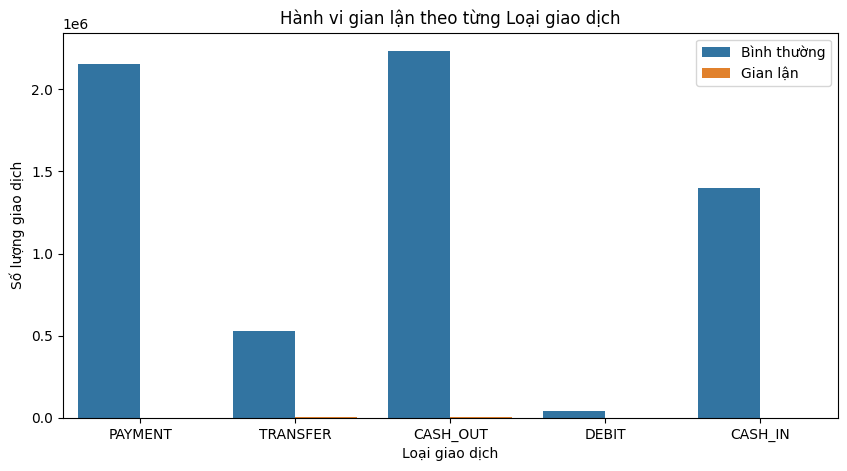

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# Vẽ biểu đồ đếm số ca gian lận theo từng loại giao dịch (type)
sns.countplot(data=df, x='type', hue='isFraud')
plt.title('Hành vi gian lận theo từng Loại giao dịch')
plt.xlabel('Loại giao dịch')
plt.ylabel('Số lượng giao dịch')
plt.legend(['Bình thường', 'Gian lận'])
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

# 1. Chuyển đổi các cột chữ (type) sang dạng số
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=True)

# 2. Bỏ các cột không dùng đến (như tên tài khoản, ký tự chữ)
cols_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud']
X = df_encoded.drop(columns=[c for c in cols_to_drop if c in df_encoded.columns] + ['isFraud'])
y = df_encoded['isFraud']

# 3. Chia tập dữ liệu Train/Test theo tỷ lệ 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Số lượng mẫu dùng để Học (Train): {X_train.shape[0]:,}")
print(f"Số lượng mẫu dùng để Thi (Test): {X_test.shape[0]:,}")

Số lượng mẫu dùng để Học (Train): 5,090,096
Số lượng mẫu dùng để Thi (Test): 1,272,524


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Khởi tạo mô hình (n_jobs=-1 giúp máy dùng hết tốc độ để chạy cho nhanh)
ai_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

print("Cỗ máy AI đang phân tích dữ liệu để học tập, bạn đợi một lát nhé...")
# 2. Tiến hành học
ai_model.fit(X_train, y_train)
print("--- ĐÃ HUẤN LUYỆN XONG! ---")

# 3. Cho AI làm bài thi thử trên tập Test
y_pred = ai_model.predict(X_test)

# 4. In báo cáo kết quả xem AI bắt trộm chuẩn không
print("\nBÁO CÁO KẾT QUẢ:")
print(classification_report(y_test, y_pred))

Cỗ máy AI đang phân tích dữ liệu để học tập, bạn đợi một lát nhé...
--- ĐÃ HUẤN LUYỆN XONG! ---

BÁO CÁO KẾT QUẢ:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      0.79      0.87      1643

    accuracy                           1.00   1272524
   macro avg       0.99      0.89      0.93   1272524
weighted avg       1.00      1.00      1.00   1272524



In [12]:
from sklearn.ensemble import IsolationForest

# 1. Khởi tạo mô hình Isolation Forest
# contamination=0.01 nghĩa là chúng ta nghi ngờ có khoảng 1% dữ liệu là gian lận
iso_forest = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)

# 2. Huấn luyện (Thuật toán này chỉ cần học trên các đặc trưng X)
iso_forest.fit(X_train)

# 3. Dự đoán: Nó sẽ trả về -1 (Bất thường/Gian lận) và 1 (Bình thường)
y_pred_iso = iso_forest.predict(X_test)

# Chuyển đổi kết quả của máy (-1 thành 1, 1 thành 0) để giống với nhãn gốc isFraud của bạn
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

# 4. In kết quả xem thám tử này làm ăn ra sao
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_iso))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1270881
           1       0.01      0.08      0.02      1643

    accuracy                           0.99   1272524
   macro avg       0.50      0.53      0.51   1272524
weighted avg       1.00      0.99      0.99   1272524



c:\Users\ADMIN\OneDrive\Desktop\New folder\th5\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


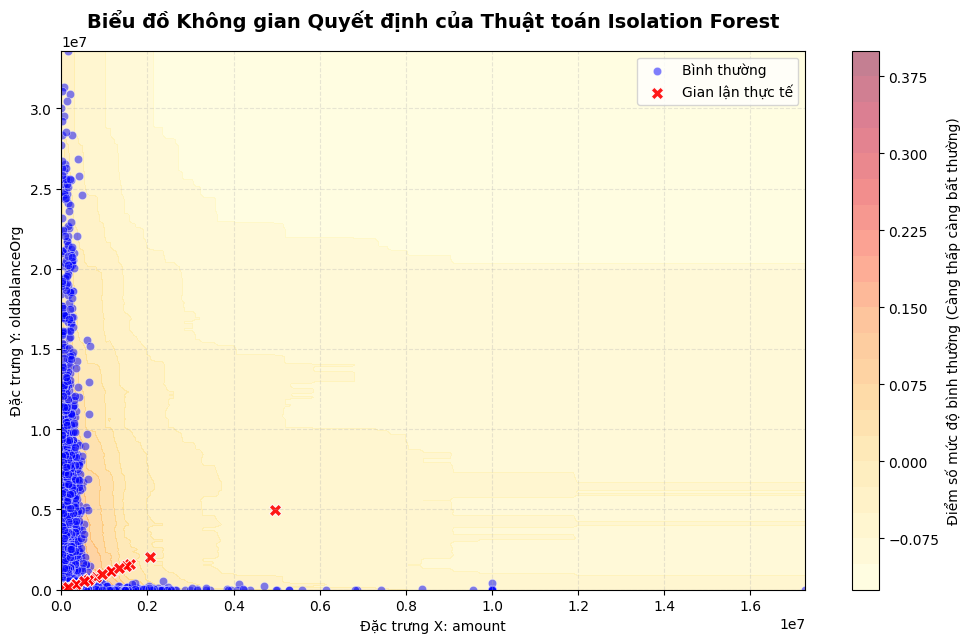

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

# 1. Chọn 2 đặc trưng quan trọng nhất để vẽ lên mặt phẳng 2D (ví dụ: Số tiền và Số dư cũ)
# Bạn có thể thay bằng 2 cột bất kỳ dạng số có trong file AIML Dataset của bạn
feature_x = 'amount'
feature_y = 'oldbalanceOrg'

# Lấy dữ liệu để vẽ (Rút gọn 10,000 dòng ngẫu nhiên để biểu đồ mượt, không bị rối)
df_sample = df.sample(n=10000, random_state=42) if len(df) > 10000 else df
X_plot = df_sample[[feature_x, feature_y]]

# 2. Huấn luyện mô hình Isolation Forest trên 2 đặc trưng này
iso_forest_plot = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)
iso_forest_plot.fit(X_plot)

# 3. Tạo một lưới tọa độ (Meshgrid) để vẽ đường ranh giới quyết định (Decision Boundary)
x_min, x_max = X_plot[feature_x].min() - 1000, X_plot[feature_x].max() + 1000
y_min, y_max = X_plot[feature_y].min() - 1000, X_plot[feature_y].max() + 1000
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Tính điểm số bất thường (Anomaly Score) cho toàn bộ lưới tọa độ
Z = iso_forest_plot.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Tiến hành vẽ biểu đồ
plt.figure(figsize=(12, 7))

# Vẽ các vùng chấm điểm của mô hình (Vùng càng đỏ/cam càng bất thường)
contour = plt.contourf(xx, yy, Z, cmap=plt.cm.YlOrRd, levels=20, alpha=0.5)
plt.colorbar(contour, label='Điểm số mức độ bình thường (Càng thấp càng bất thường)')

# Vẽ các điểm dữ liệu thực tế lên biểu đồ
# Giao dịch bình thường (isFraud = 0) vẽ màu xanh
sns.scatterplot(
    data=df_sample[df_sample['isFraud'] == 0], 
    x=feature_x, y=feature_y, 
    color='blue', alpha=0.5, label='Bình thường'
)

# Giao dịch gian lận (isFraud = 1) vẽ màu đỏ rực rỡ để làm nổi bật
sns.scatterplot(
    data=df_sample[df_sample['isFraud'] == 1], 
    x=feature_x, y=feature_y, 
    color='red', alpha=0.9, s=80, marker='X', label='Gian lận thực tế'
)

# Thiết lập tiêu đề và nhãn
plt.title('Biểu đồ Không gian Quyết định của Thuật toán Isolation Forest', fontsize=14, fontweight='bold')
plt.xlabel(f'Đặc trưng X: {feature_x}')
plt.ylabel(f'Đặc trưng Y: {feature_y}')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)

# Hiển thị biểu đồ ngay trong VS Code
plt.show()

In [14]:
from sklearn.ensemble import IsolationForest

# 1. Khởi tạo mô hình Isolation Forest
# contamination=0.01 nghĩa là ta thiết lập tỷ lệ bất thường dự kiến khoảng 1%
iso_forest = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)

# 2. Cho mô hình học các đặc trưng (X_train đã chuẩn bị ở ô code số 4 trước đó)
iso_forest.fit(X_train)

# 3. Tiến hành dự đoán trên tập dữ liệu kiểm tra (X_test)
y_pred_iso = iso_forest.predict(X_test)

# 4. Đếm số lượng kết quả Bình thường (1) và Bất thường (-1) mà máy tìm được
bình_thường = (y_pred_iso == 1).sum()
bất_thường = (y_pred_iso == -1).sum()

# 5. In kết quả ra màn hình
print("--- KẾT QUẢ PHÂN LOẠI CỦA ISOLATION FOREST ---")
print(f"Số lượng giao dịch BÌNH THƯỜNG (mã 1):  {bình_thường:,} giao dịch")
print(f"Số lượng giao dịch BẤT THƯỜNG (mã -1): {bất_thường:,} giao dịch")

--- KẾT QUẢ PHÂN LOẠI CỦA ISOLATION FOREST ---
Số lượng giao dịch BÌNH THƯỜNG (mã 1):  1,259,858 giao dịch
Số lượng giao dịch BẤT THƯỜNG (mã -1): 12,666 giao dịch


In [8]:
%pip install seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.2 MB 12.5 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 27.0 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 44.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 56.3 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/8 [pyparsing]
   ---------------------------------------- 0/8 [pyparsing]
   -------------


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
